# **Zomato Regression Project**

**Domain:** Data Science & Machine Learning

**Sub-domain:** Machine Learning

**Problem Type:** Regression

**Application Area:** Restaurant / Food Service Analytics

**Target:** Restaurant Aggregate Rating

**Tools:** Python, Google Colab, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

# **Project Goal**
To develop a regression model that predicts restaurant aggregate ratings using relevant features from the Zomato dataset and evaluate the model's performance using appropriate regression metrics.

# **Problem Statement**
Zomato contains a large amount of restaurant information, including ratings, votes, average cost, online delivery, and table booking. It can be difficult to predict the aggregate rating of a restaurant based on these factors. Therefore, this project uses machine learning regression algorithms to predict the aggregate rating of Zomato restaurants and identify the best-performing model.

# **Objectives**
The main objective of this project is to predict the aggregate rating of Zomato restaurants using machine learning. It also aims to analyze restaurant details, compare different regression models, and select the best-performing model for accurate rating prediction.

# **Future Scope**
1.The project can be improved by using more restaurant features.

2.More machine learning regression algorithms can be tested.

3.Hyperparameter tuning can be used to improve model performance.

4.The model can be developed into a web application.

5.A restaurant recommendation system can be added.

6.Real-time Zomato data can be used for better predictions.

7.An interactive dashboard can be created to show restaurant insights.

# Loading Dataset

In [326]:
import pandas as pd
import numpy as np

In [327]:
# Load the Zomato dataset

df = pd.read_csv('/content/Zomato.csv', encoding='latin1')

#Understanding Dataset

In [328]:
# Display first 5 rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [329]:
# Display number of rows and columns

df.shape

(9551, 21)

In [330]:
#Get dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [331]:
# Display statistical information
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


# Handling Missing Values

In [332]:
#Checking missing values

df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [333]:
# Show only columns containing missing values

df.isnull().sum()[df.isnull().sum() > 0]

,0
Cuisines,9


In [334]:
# Missing-value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

,0
Cuisines,0.094231


In [335]:
#filling missing values
df["Cuisines"]=df["Cuisines"].fillna(df["Cuisines"].mode)


In [336]:
#Again checking missing values

df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


# Handling Duplicate Values

In [337]:
#Checking duplicate records

df.duplicated().sum()

np.int64(0)

In [338]:
# Remove duplicates
df = df.drop_duplicates()

In [339]:
#Again check duplicate records

df.duplicated().sum()

np.int64(0)

# Data Cleaning

In [340]:
invalid_rating = ((df["Aggregate rating"] < 0) |
                  (df["Aggregate rating"] > 5)).sum()

print("Invalid Aggregate rating values:", invalid_rating)

Invalid Aggregate rating values: 0


In [341]:
invalid_price_range = ((df["Price range"] < 1) |
                       (df["Price range"] > 4)).sum()

print("Invalid Price range values:", invalid_price_range)

Invalid Price range values: 0


In [342]:
invalid_votes = (df["Votes"] < 0).sum()

print("Negative Votes:", invalid_votes)

Negative Votes: 0


In [343]:
invalid_cost = (df["Average Cost for two"] < 0).sum()

print("Negative Average Cost for two:", invalid_cost)

Negative Average Cost for two: 0


# EDA Preparation

In [344]:
print("Statistical summary of numerical columns:")
df.describe()

Statistical summary of numerical columns:


,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [345]:
print("Statistical summary of categorical columns:")
df.describe(include='object')

Statistical summary of categorical columns:


,Restaurant Name,City,Address,Locality,Locality Verbose,Cuisines,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Rating color,Rating text
count,9551,9551,9551,9551,9551,9551,9551,9551,9551,9551,9551,9551,9551
unique,7446,141,8918,1208,1265,1826,12,2,2,2,1,6,6
top,Cafe Coffee Day,New Delhi,"Dilli Haat, INA, New Delhi",Connaught Place,"Connaught Place, New Delhi",North Indian,Indian Rupees(Rs.),No,No,No,No,Orange,Average
freq,83,5473,11,122,122,936,8652,8393,7100,9517,9551,3737,3737


In [346]:
#check unique values
print("Number of unique values in each column:")
print(df.nunique())

Number of unique values in each column:
Restaurant ID           9551
Restaurant Name         7446
Country Code              15
City                     141
Address                 8918
Locality                1208
Locality Verbose        1265
Longitude               8120
Latitude                8677
Cuisines                1826
Average Cost for two     140
Currency                  12
Has Table booking          2
Has Online delivery        2
Is delivering now          2
Switch to order menu       1
Price range                4
Aggregate rating          33
Rating color               6
Rating text                6
Votes                   1012
dtype: int64


In [347]:
print("Aggregate rating summary:")
print(df["Aggregate rating"].describe())

Aggregate rating summary:
count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


# Univariate Analysis

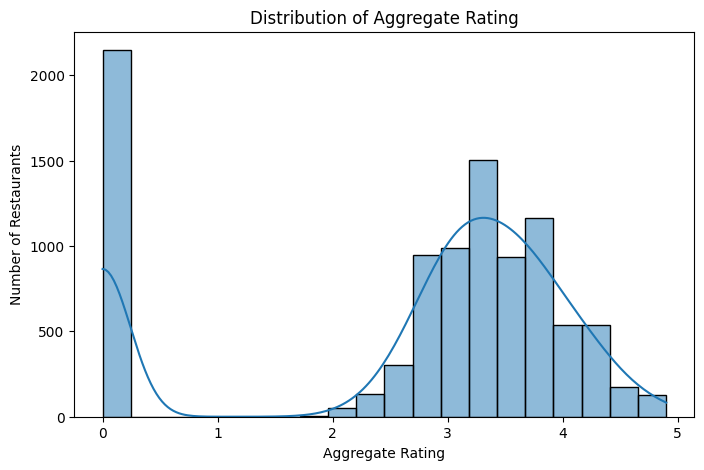

In [348]:
#Rating analysis
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["Aggregate rating"], bins=20, kde=True)
plt.title("Distribution of Aggregate Rating")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.show()

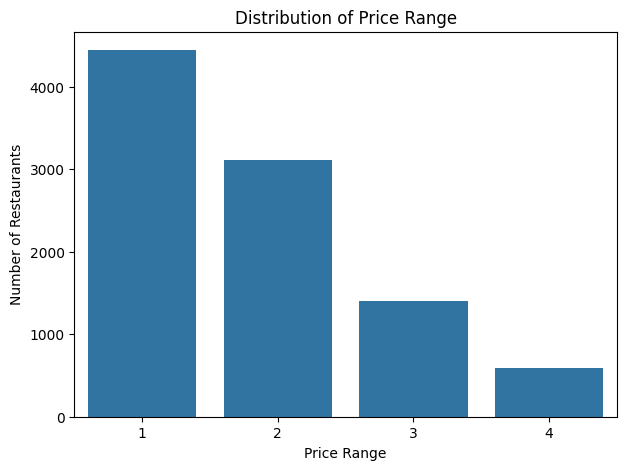

In [349]:
#price range
plt.figure(figsize=(7, 5))
sns.countplot(x=df["Price range"])
plt.title("Distribution of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()

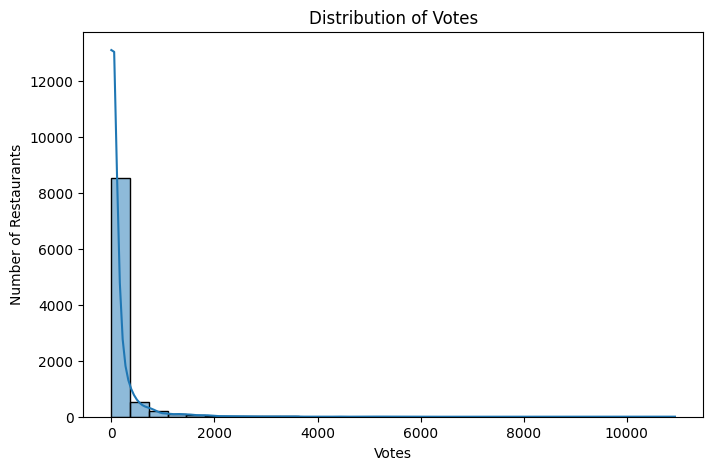

In [350]:
#votes analysis
plt.figure(figsize=(8, 5))
sns.histplot(df["Votes"], bins=30, kde=True)
plt.title("Distribution of Votes")
plt.xlabel("Votes")
plt.ylabel("Number of Restaurants")
plt.show()

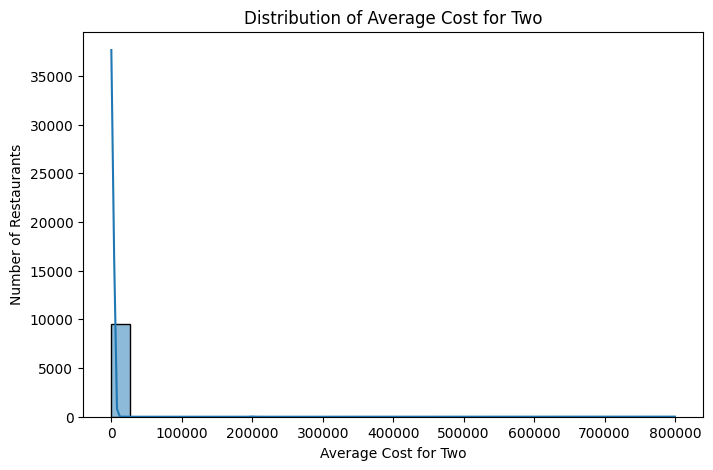

In [351]:
#average cost
plt.figure(figsize=(8, 5))
sns.histplot(df["Average Cost for two"], bins=30, kde=True)
plt.title("Distribution of Average Cost for Two")
plt.xlabel("Average Cost for Two")
plt.ylabel("Number of Restaurants")
plt.show()

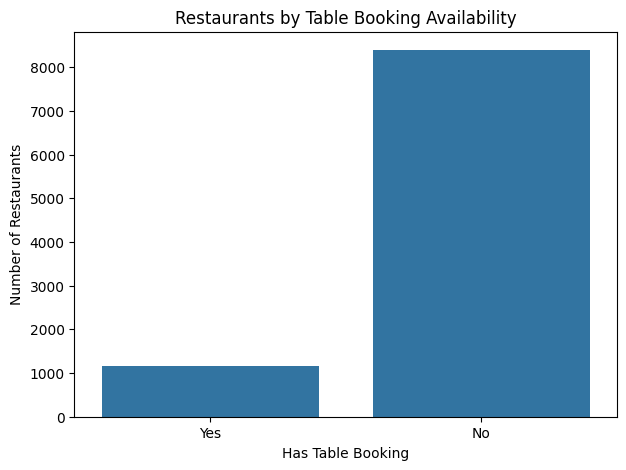

In [352]:
#Table booking analysis
plt.figure(figsize=(7, 5))
sns.countplot(x=df["Has Table booking"])
plt.title("Restaurants by Table Booking Availability")
plt.xlabel("Has Table Booking")
plt.ylabel("Number of Restaurants")
plt.show()

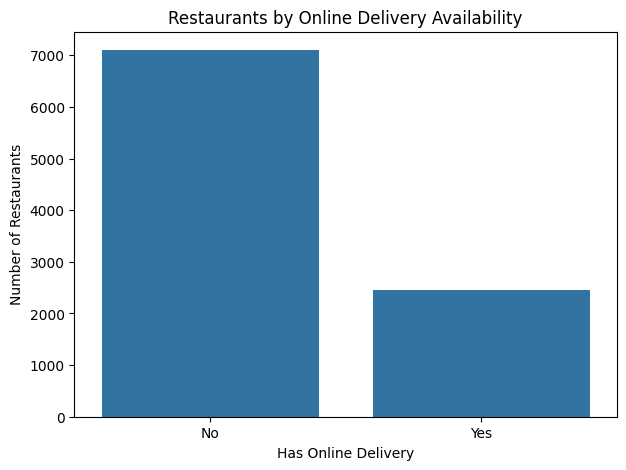

In [353]:
#Online delivery analysis
plt.figure(figsize=(7, 5))
sns.countplot(x=df["Has Online delivery"])
plt.title("Restaurants by Online Delivery Availability")
plt.xlabel("Has Online Delivery")
plt.ylabel("Number of Restaurants")
plt.show()

# Bivariate Analysis

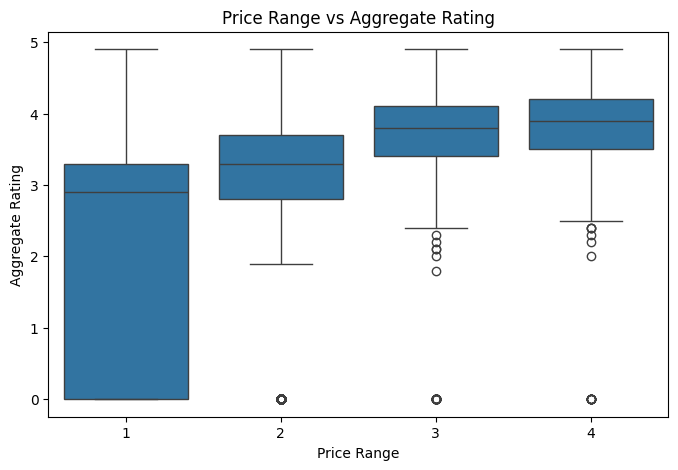

In [354]:
#Price Range vs Rating
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Price range",
    y="Aggregate rating",
    data=df
)

plt.title("Price Range vs Aggregate Rating")
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")
plt.show()

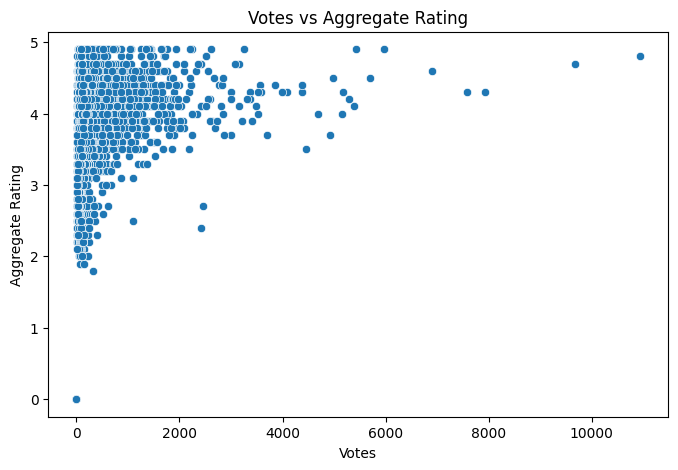

In [355]:
#Rating vs Votes
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Votes",
    y="Aggregate rating",
    data=df
)

plt.title("Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")
plt.show()

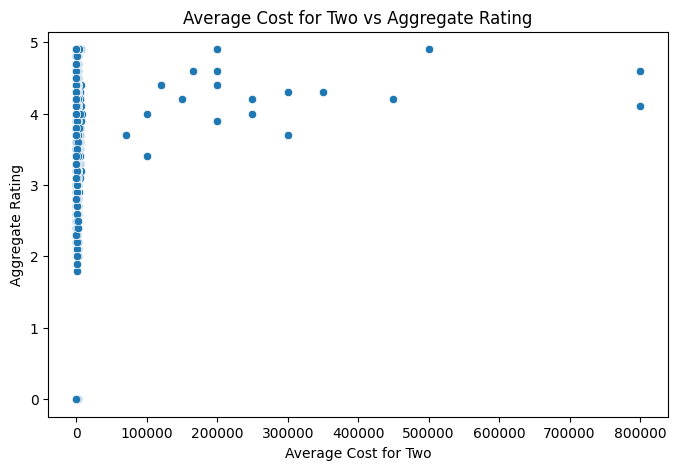

In [356]:
#Average cost vs rating
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Average Cost for two",
    y="Aggregate rating",
    data=df
)

plt.title("Average Cost for Two vs Aggregate Rating")
plt.xlabel("Average Cost for Two")
plt.ylabel("Aggregate Rating")
plt.show()

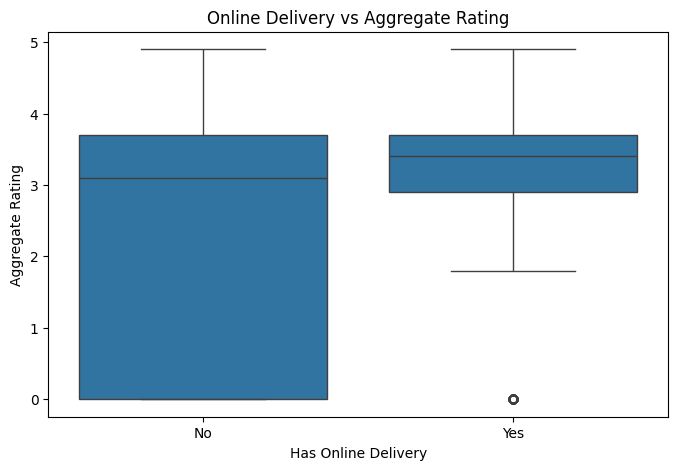

In [357]:
# Online delivery vs rating
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Has Online delivery",
    y="Aggregate rating",
    data=df
)

plt.title("Online Delivery vs Aggregate Rating")
plt.xlabel("Has Online Delivery")
plt.ylabel("Aggregate Rating")
plt.show()

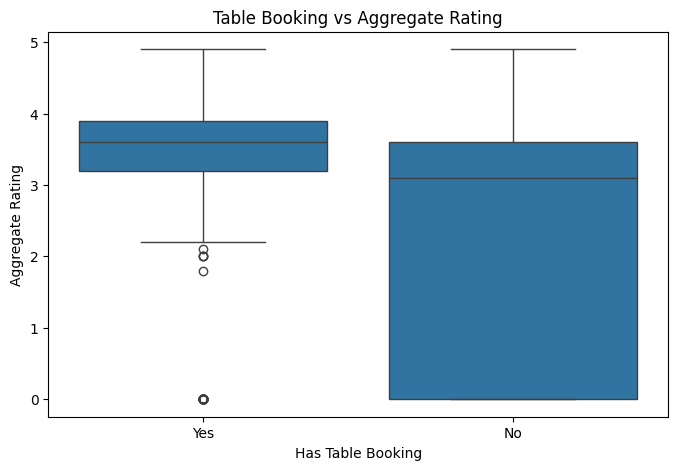

In [358]:
#Table booking vs rating
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Has Table booking",
    y="Aggregate rating",
    data=df
)

plt.title("Table Booking vs Aggregate Rating")
plt.xlabel("Has Table Booking")
plt.ylabel("Aggregate Rating")
plt.show()

# Multivariate Analysis

In [359]:
#correlation
numerical_columns = [
    "Longitude",
    "Latitude",
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes"
]

correlation = df[numerical_columns].corr()

print(correlation)

                      Longitude  Latitude  Average Cost for two  Price range  \
Longitude              1.000000  0.043207              0.045891    -0.078939   
Latitude               0.043207  1.000000             -0.111088    -0.166688   
Average Cost for two   0.045891 -0.111088              1.000000     0.075083   
Price range           -0.078939 -0.166688              0.075083     1.000000   
Aggregate rating      -0.116818  0.000516              0.051792     0.437944   
Votes                 -0.085101 -0.022962              0.067783     0.309444   

                      Aggregate rating     Votes  
Longitude                    -0.116818 -0.085101  
Latitude                      0.000516 -0.022962  
Average Cost for two          0.051792  0.067783  
Price range                   0.437944  0.309444  
Aggregate rating              1.000000  0.313691  
Votes                         0.313691  1.000000  


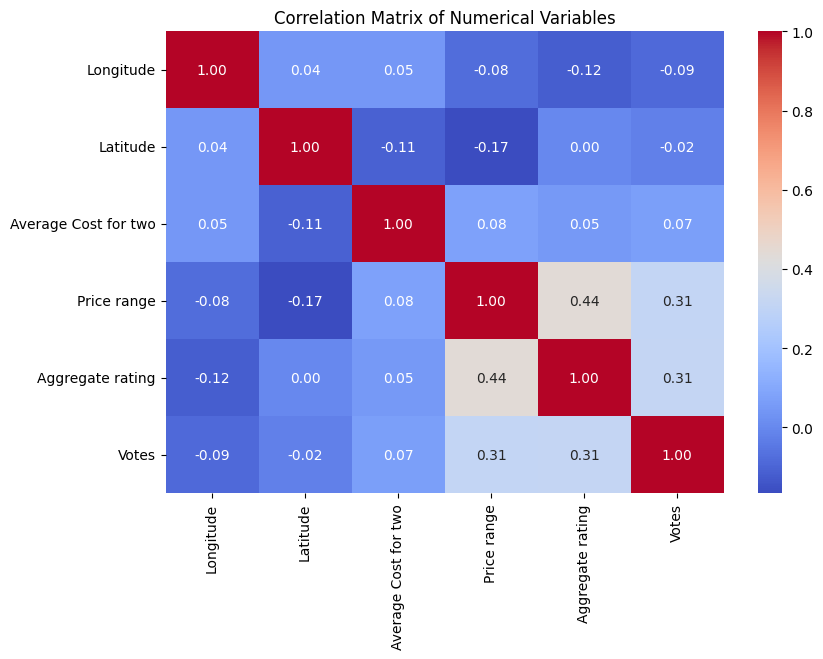

In [360]:
#Correlation Heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

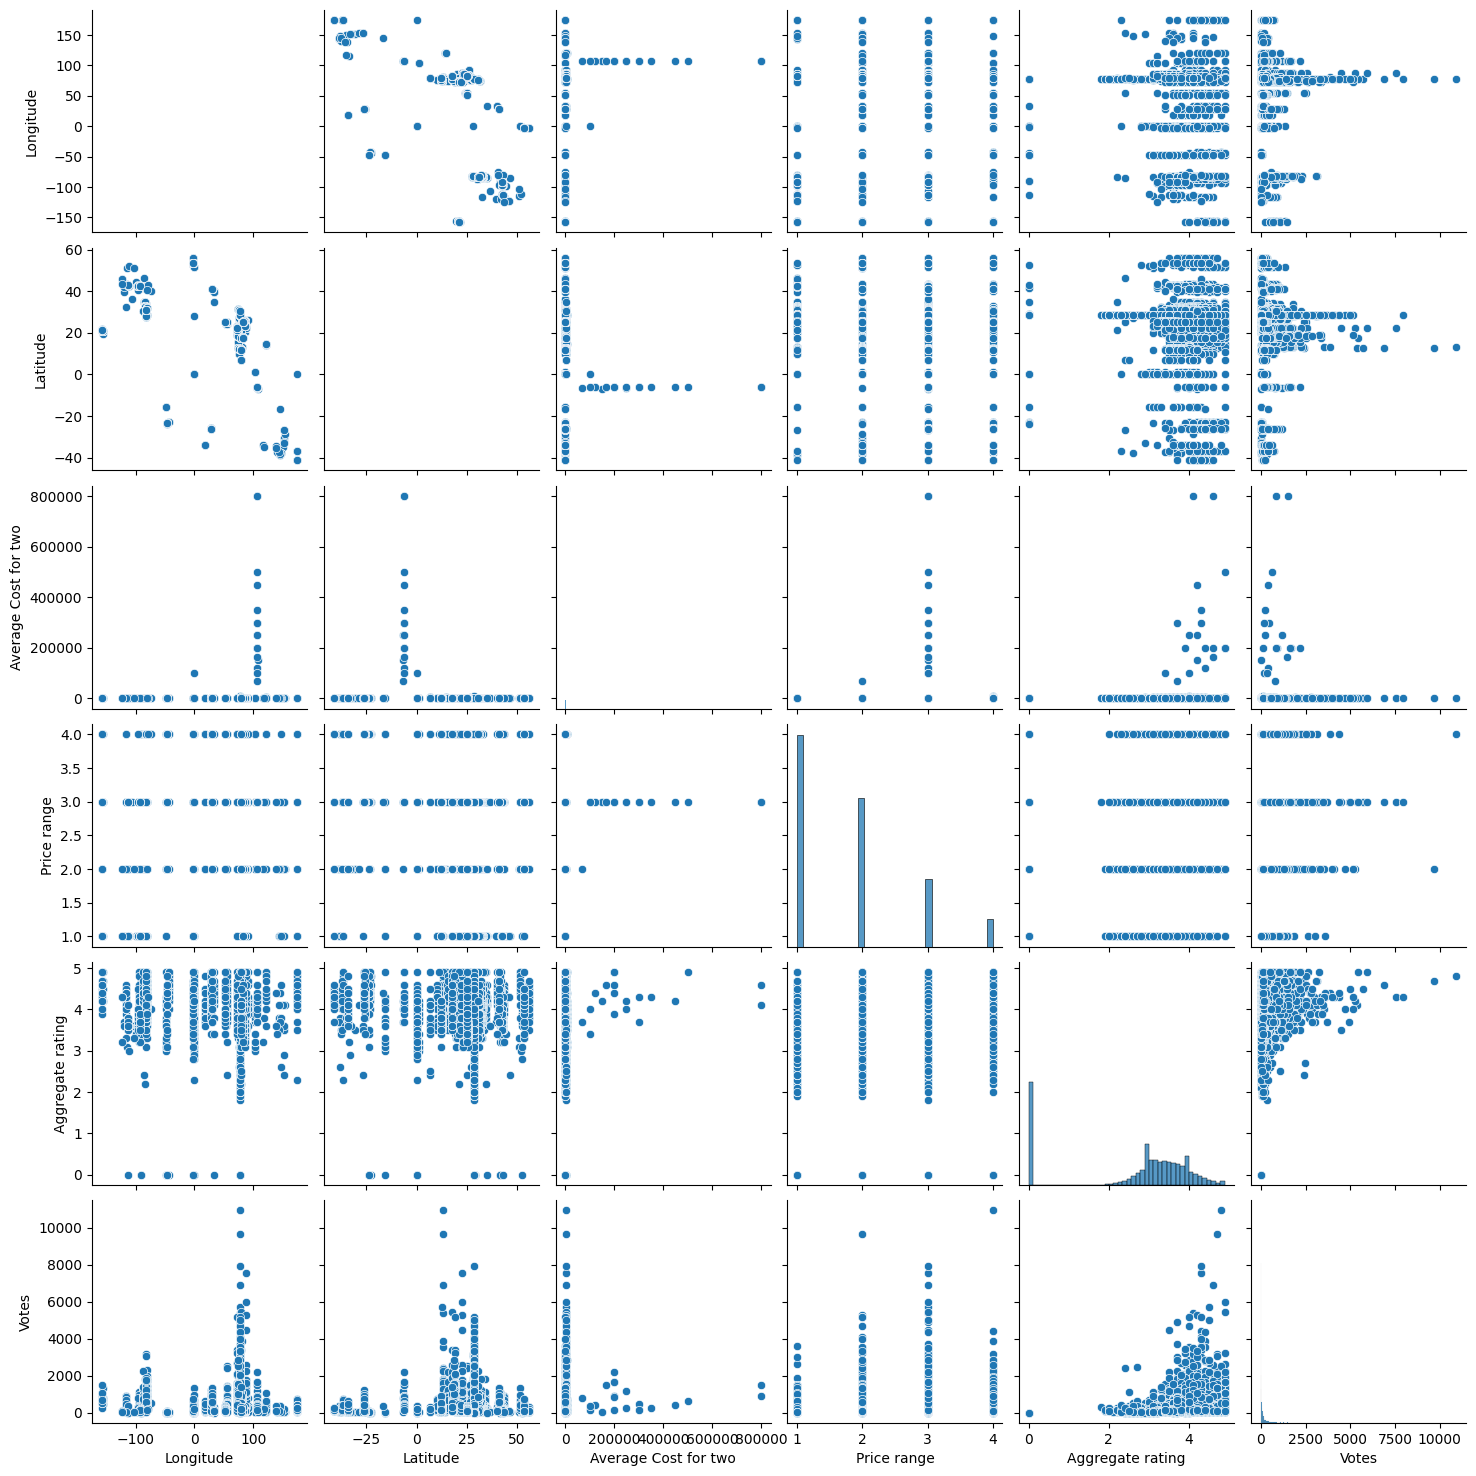

In [361]:
#pair plot for numerical columns
sns.pairplot(
    df[numerical_columns]
)
plt.show()

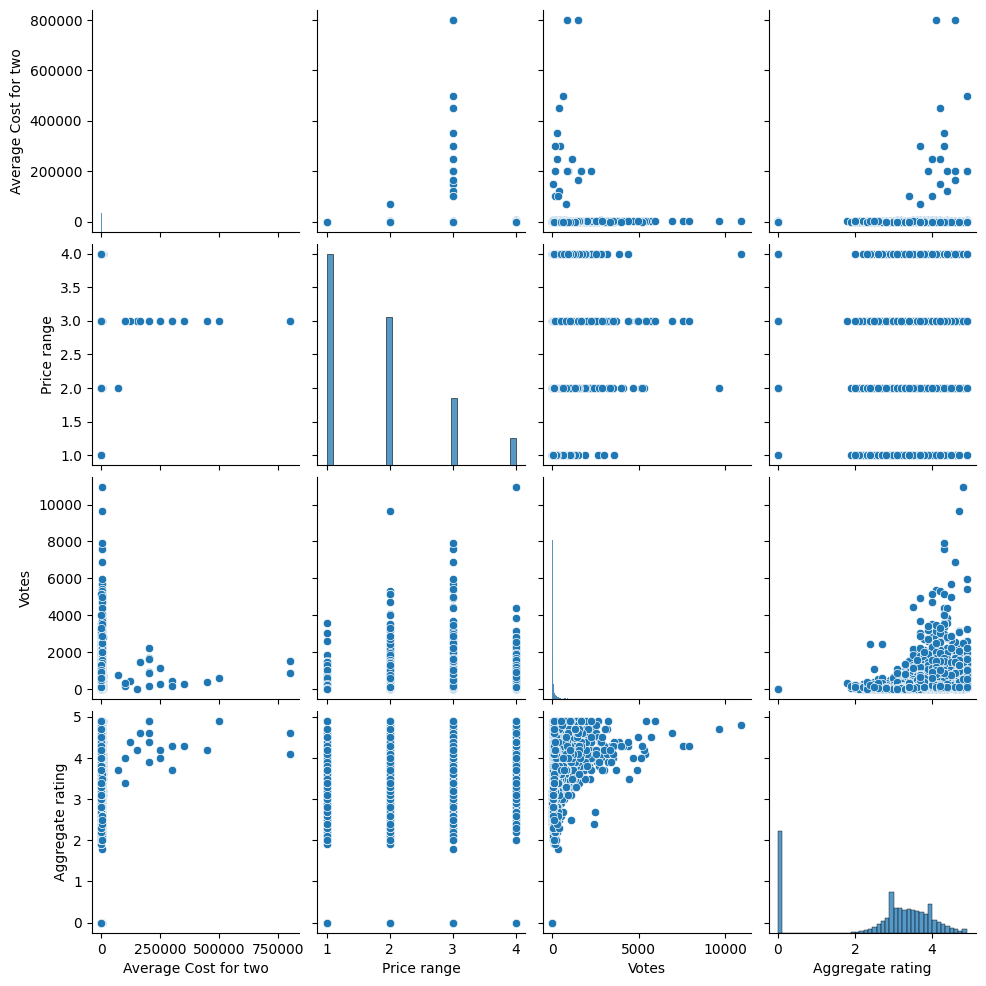

In [362]:
#pair plot for selected columns
selected_columns = [
    "Average Cost for two",
    "Price range",
    "Votes",
    "Aggregate rating"
]

sns.pairplot(
    df[selected_columns]
)

plt.show()

#Outliers Handling

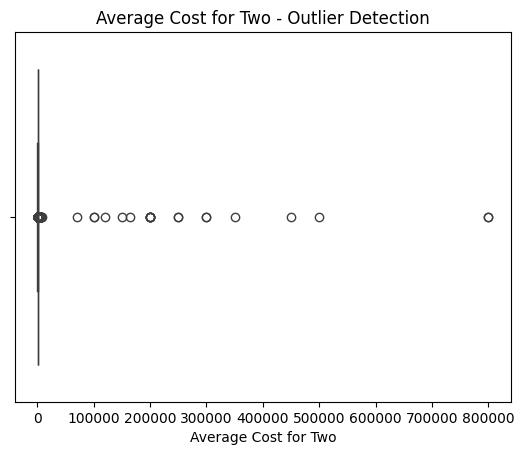

In [363]:
#Average Cost for Two - Outlier Detection
sns.boxplot(x=df['Average Cost for two'])

plt.title("Average Cost for Two - Outlier Detection")
plt.xlabel("Average Cost for Two")
plt.show()

In [364]:
Q1 = df['Average Cost for two'].quantile(0.25)
Q3 = df['Average Cost for two'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 250.0
Q3: 700.0
IQR: 450.0
Lower Limit: -425.0
Upper Limit: 1375.0


In [365]:
# Remove outliers
df = df[
    (df['Average Cost for two'] >= lower_limit) &
    (df['Average Cost for two'] <= upper_limit)
]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (8698, 21)


#Feature Engineering

In [366]:
df["Table booking"] = df["Has Table booking"].map({
    "Yes": 1,
    "No": 0
})
print(df[["Has Table booking", "Table booking"]].head())

   Has Table booking  Table booking
0                Yes              1
1                Yes              1
5                 No              0
9                Yes              1
10                No              0


In [367]:
df["Online delivery"] = df["Has Online delivery"].map({
    "Yes": 1,
    "No": 0
})
print(df[["Has Online delivery", "Online delivery"]].head())

   Has Online delivery  Online delivery
0                   No                0
1                   No                0
5                   No                0
9                   No                0
10                  No                0


In [368]:
df["Delivering now"] = df["Is delivering now"].map({
    "Yes": 1,
    "No": 0
})
print(df[["Is delivering now", "Delivering now"]].head())

   Is delivering now  Delivering now
0                 No               0
1                 No               0
5                 No               0
9                 No               0
10                No               0


In [369]:
print(df[[
    "Has Table booking",
    "Table booking",
    "Has Online delivery",
    "Online delivery",
    "Is delivering now",
    "Delivering now"
]].head())

   Has Table booking  Table booking Has Online delivery  Online delivery  \
0                Yes              1                  No                0   
1                Yes              1                  No                0   
5                 No              0                  No                0   
9                Yes              1                  No                0   
10                No              0                  No                0   

   Is delivering now  Delivering now  
0                 No               0  
1                 No               0  
5                 No               0  
9                 No               0  
10                No               0  


# Feature Selection & Target Selection

In [370]:
# Selecting Useful features
X = df[
    [
        "Average Cost for two",
        "Price range",
        "Votes",
        "Table booking",
        "Online delivery",
        "Delivering now",
        "Longitude",
        "Latitude"
    ]
]

In [371]:
# Select target variabe
y = df["Aggregate rating"]

In [372]:
# Check selected features
print("Selected features:")
print(X.columns)

Selected features:
Index(['Average Cost for two', 'Price range', 'Votes', 'Table booking',
       'Online delivery', 'Delivering now', 'Longitude', 'Latitude'],
      dtype='object')


In [373]:
# Check target
print("\nTarget:")
print(y.name)


Target:
Aggregate rating


In [374]:
# Check shapes
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (8698, 8)
Target shape: (8698,)


# Encoding Categorical Data

In [375]:
print("Feature data types:")
print(X.dtypes)

Feature data types:
Average Cost for two      int64
Price range               int64
Votes                     int64
Table booking             int64
Online delivery           int64
Delivering now            int64
Longitude               float64
Latitude                float64
dtype: object


In [376]:
print("\nCategorical columns in X:")
print(X.select_dtypes(include="object").columns)


Categorical columns in X:
Index([], dtype='object')


In [377]:
print("\nFirst 5 rows of X:")
display(X.head())


First 5 rows of X:


,Average Cost for two,Price range,Votes,Table booking,Online delivery,Delivering now,Longitude,Latitude
0,1100,3,314,1,0,0,121.027535,14.565443
1,1200,3,591,1,0,0,121.014101,14.553708
5,1000,3,336,0,0,0,121.056314,14.583764
9,1100,3,532,1,0,0,121.056532,14.572041
10,800,3,1070,0,0,0,121.057916,14.567689


# Train-Test Split

In [378]:
from sklearn.model_selection import train_test_split

In [379]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [380]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6958, 8)
X_test shape: (1740, 8)
y_train shape: (6958,)
y_test shape: (1740,)


# Train Regression Models

In [381]:
#import libraries
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [382]:
# Logistic Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [383]:
#Decision Tree
decision_tree_model = DecisionTreeRegressor(
    random_state=42
)
decision_tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [384]:
# Random Forest
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
random_forest_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [385]:
#predictions
y_pred_linear = linear_model.predict(X_test)
y_pred_tree = decision_tree_model.predict(X_test)
y_pred_forest = random_forest_model.predict(X_test)

# Evaluate & compare models

In [386]:
#import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [387]:
#Calculate metrics for Linear Regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

In [388]:
#Calculate metrics for Decision Tree
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

In [389]:
#Calculate metrics for Random Forest
mae_forest = mean_absolute_error(y_test, y_pred_forest)
mse_forest = mean_squared_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mse_forest)
r2_forest = r2_score(y_test, y_pred_forest)

In [390]:
#Create a comparison table
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_forest
    ],
    "MSE": [
        mse_linear,
        mse_tree,
        mse_forest
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_forest
    ],
    "R2 Score": [
        r2_linear,
        r2_tree,
        r2_forest
    ]
})

display(results)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.099596,1.687579,1.299069,0.265487
1,Decision Tree Regression,0.279511,0.192013,0.438193,0.916427
2,Random Forest Regression,0.204534,0.100999,0.317803,0.956041


In [391]:
#find a best model
best_model_name = results.loc[results["RMSE"].idxmin(), "Model"]

print("Model with lowest RMSE:")
print(best_model_name)

Model with lowest RMSE:
Random Forest Regression


In [392]:
model_map = {
    "Linear Regression": linear_model,
    "Decision Tree Regression": decision_tree_model,
    "Random Forest Regression": random_forest_model
}

final_model = model_map[best_model_name]

print("Final model selected:", best_model_name)

Final model selected: Random Forest Regression


# Predictions & final insights

In [393]:
#prediction using test data
final_predictions = final_model.predict(X_test)

print("First 10 predicted Aggregate Ratings:")
print(final_predictions[:10])

First 10 predicted Aggregate Ratings:
[0.    3.002 3.65  3.556 3.118 2.985 3.366 3.87  3.069 4.442]


In [394]:
#Create Actual vs Predicted Table
final_prediction_table = df.loc[
    X_test.index,
    ["Aggregate rating"]
].copy()

final_prediction_table["Predicted Aggregate rating"] = final_predictions

display(final_prediction_table.head(10))

,Aggregate rating,Predicted Aggregate rating
8338,0.0,0.000
4410,2.8,3.002
7198,4.2,3.650
691,3.4,3.556
1361,3.1,3.118
6067,2.9,2.985
2707,3.5,3.366
89,3.9,3.870
8733,3.0,3.069
324,4.9,4.442


In [395]:
# Example new restaurant for final prediction

new_restaurant = pd.DataFrame({
    "Average Cost for two": [800],
    "Price range": [2],
    "Votes": [250],
    "Table booking": [1],
    "Online delivery": [1],
    "Delivering now": [0],
    "Longitude": [78.48],
    "Latitude": [17.40]
})

# Predict Aggregate Rating
predicted_rating = final_model.predict(new_restaurant)

# Keep prediction within the rating scale of 0 to 5
predicted_rating = np.clip(predicted_rating, 0, 5)

print("Predicted Aggregate Rating:", round(predicted_rating[0], 2))

Predicted Aggregate Rating: 4.05


In [396]:
# complete metrics of the best model
final_metrics = results[
    results["Model"] == best_model_name
]

display(final_metrics)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest Regression,0.204534,0.100999,0.317803,0.956041


# Final Project Conclusion
The Zomato regression project predicts restaurant Aggregate Rating using restaurant features such as votes, average cost, price range, online delivery, table booking, and location. Three regression algorithms were evaluated. Random Forest Regression was selected as the final model because it provided better overall prediction performance based on the evaluation metrics, making it suitable for predicting restaurant ratings in this dataset.